In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import os
from PIL import Image
import numpy as np
from tqdm.auto import tqdm  # これを追加

DATA_DIR = '/mnt/data1/gotou/kaggle/pcam'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train')
LABELS_CSV = os.path.join(DATA_DIR, 'train_labels.csv')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test')

# 出力ディレクトリ（画像・リザルト保存先）
OUTPUT_DIR = '/mnt/data1/gotou/kaggle/jpeg'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# データ拡張（学習時のみ）
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PCamDataset(Dataset):
    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir = img_dir
        self.labels = labels_df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        img_id = self.labels.iloc[idx, 0]
        label = self.labels.iloc[idx, 1]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

labels_df = pd.read_csv(LABELS_CSV)
train_df, val_df = train_test_split(labels_df, test_size=0.1, random_state=42, stratify=labels_df['label'])

train_dataset = PCamDataset(TRAIN_IMG_DIR, train_df, train_transform)
val_dataset = PCamDataset(TRAIN_IMG_DIR, val_df, val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=4)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

resnet50.fc = nn.Linear(resnet50.fc.in_features, 1)
model = resnet50.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# モデル定義（学習時と同じ）
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)  # 1ユニット出力
model = model.to(device)

# 重みロード
ckpt_path = "/mnt/data1/gotou/kaggle/pcam/best_model_weights.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model from {ckpt_path}")


/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded model from /mnt/data1/gotou/kaggle/pcam/best_model_weights.pth


PGD攻撃 (ddpm_pgd と同一設定) + JPEG防御（jpeg_fgsm2 と同一手法）による評価

- 対象データ: PCam 検証セット
- 評価対象: 元画像で正解したサンプルのみ
- 攻撃: PGD (ε=8/255, α=2/255, steps=10, random start)
- 防御: JPEG圧縮 (quality=11)
- 出力: 精度、混同行列、CSV

In [2]:
# 攻撃関数: ddpm_pgd と同一の PGD 実装 (L∞, per-channel 正規化対応)
import torch.nn.functional as F

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def denormalize(x, mean, std):
    return x * std + mean

def renormalize(x_pixel, mean, std):
    return (x_pixel - mean) / std


def pgd_attack_improved(
    model,
    images,
    labels,
    epsilon_pixel,      # 例: 8/255 (float) or shape [C]
    alpha_pixel,        # 例: 2/255 (float) or shape [C]
    steps=10,
    device=None,
    mean_tensor=None,
    std_tensor=None,
    random_start=True,
    return_preds=True,
):
    if mean_tensor is None or std_tensor is None:
        mean_tensor_local = mean
        std_tensor_local = std
    else:
        mean_tensor_local = mean_tensor
        std_tensor_local = std_tensor
    if device is None:
        device = images.device

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    B, C, H, W = images.shape

    def _to_channel_tensor(x):
        if not torch.is_tensor(x):
            t = torch.tensor(x, dtype=images.dtype, device=device)
        else:
            t = x.to(device).to(images.dtype)
        if t.ndim == 0:
            t = t.view(1, 1, 1, 1)
        elif t.ndim == 1 and t.numel() == C:
            t = t.view(1, C, 1, 1)
        else:
            t = t.view(1, -1, 1, 1)
        return t

    eps_pixel_t = _to_channel_tensor(epsilon_pixel)
    alpha_pixel_t = _to_channel_tensor(alpha_pixel)

    # 正規化空間でのε, α
    eps_norm = eps_pixel_t / std_tensor_local.to(images.dtype)
    alpha_norm = alpha_pixel_t / std_tensor_local.to(images.dtype)

    # 元のピクセル画像
    orig_pixel = denormalize(images, mean_tensor_local, std_tensor_local)

    # ランダムスタート
    if random_start:
        uni = torch.empty_like(orig_pixel).uniform_(-1.0, 1.0)
        rand_pert = uni * eps_pixel_t
        adv_pixel = torch.clamp(orig_pixel + rand_pert, 0.0, 1.0)
        adv_images = renormalize(adv_pixel, mean_tensor_local, std_tensor_local).detach()
    else:
        adv_images = images.clone().detach()

    for _ in range(steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        if outputs.ndim > 1 and outputs.shape[1] == 1:
            outputs = outputs.squeeze(1)
        loss = F.binary_cross_entropy_with_logits(outputs, labels.float())
        model.zero_grad()
        loss.backward()
        grad = adv_images.grad.data

        # 符号で更新（正規化空間）
        adv_images = adv_images + alpha_norm * grad.sign()

        # L∞射影（ピクセル空間での投影）
        adv_pixel = denormalize(adv_images, mean_tensor_local, std_tensor_local)
        eta = torch.clamp(adv_pixel - orig_pixel, min=-eps_pixel_t, max=eps_pixel_t)
        adv_pixel = torch.clamp(orig_pixel + eta, 0.0, 1.0)

        # 正規化へ戻す
        adv_images = renormalize(adv_pixel, mean_tensor_local, std_tensor_local).detach()
        adv_images.requires_grad = False
        del grad, outputs, loss, eta, adv_pixel
        torch.cuda.empty_cache()

    if return_preds:
        with torch.no_grad():
            adv_out = model(adv_images)
            if adv_out.ndim > 1 and adv_out.shape[1] == 1:
                adv_out = adv_out.squeeze(1)
            adv_probs = torch.sigmoid(adv_out)
            adv_preds = (adv_probs > 0.5).long().cpu()
        return adv_images, adv_preds

    return adv_images


In [3]:
# JPEG圧縮による防御（jpeg_fgsm2 と同一処理）
import io
from PIL import Image

def jpeg_compression_defense(images, quality=11, mean_tensor=None, std_tensor=None):
    if mean_tensor is None or std_tensor is None:
        mean_tensor = mean
        std_tensor = std
    defended_images = []
    for i in range(images.shape[0]):
        img_pixel = denormalize(images[i:i+1], mean_tensor, std_tensor)
        img_pil = transforms.ToPILImage()(img_pixel.squeeze(0).cpu())
        buf = io.BytesIO()
        img_pil.save(buf, format='JPEG', quality=quality)
        buf.seek(0)
        img_jpeg = Image.open(buf).convert('RGB')
        img_tensor = transforms.ToTensor()(img_jpeg).unsqueeze(0).to(images.device)
        img_norm = renormalize(img_tensor, mean_tensor, std_tensor)
        defended_images.append(img_norm)
    return torch.cat(defended_images, dim=0)


In [4]:
# 評価: 元画像で正解したサンプルのみ対象に、PGD + JPEG防御を適用
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# パラメータ (ddpm_pgd と同一)
epsilon = 8/255.0
alpha = 2/255.0
pgd_steps = 10
jpeg_quality = 11
chunk_bs = 8

all_labels = []
all_preds_clean = []
all_preds_adv = []
all_preds_def = []

# ノルム計算用リスト（ddpm_pgd と同様）
l2_norms_adv = []
linf_norms_adv = []
l2_norms_purified = []
linf_norms_purified = []

print(f"評価開始: epsilon={epsilon:.4f}, alpha={alpha:.4f}, steps={pgd_steps}, JPEG Q={jpeg_quality}")
print("正解した画像のみを評価対象とします")
print("="*60)

for images, labels in tqdm(val_loader, desc="Evaluation"):
    images = images.to(device)
    labels = labels.to(device)

    # 元画像での予測
    with torch.no_grad():
        out = model(images)
        if out.ndim > 1 and out.shape[1] == 1:
            out = out.squeeze(1)
        probs = torch.sigmoid(out)
        preds = (probs > 0.5).long()

    # 正解のみフィルタ
    correct_mask = (preds == labels)
    if correct_mask.sum() == 0:
        continue
    x = images[correct_mask]
    y = labels[correct_mask]
    p_clean = preds[correct_mask].cpu()

    # PGD攻撃（分割）
    adv_imgs_list, adv_preds_list = [], []
    for i in range(0, x.size(0), chunk_bs):
        xi = x[i:i+chunk_bs]
        yi = y[i:i+chunk_bs]
        adv_i, pred_i = pgd_attack_improved(
            model=model,
            images=xi,
            labels=yi,
            epsilon_pixel=epsilon,
            alpha_pixel=alpha,
            steps=pgd_steps,
            device=device,
            mean_tensor=mean,
            std_tensor=std,
            random_start=True,
            return_preds=True,
        )
        adv_imgs_list.append(adv_i)
        adv_preds_list.append(pred_i)
        torch.cuda.empty_cache()
    adv = torch.cat(adv_imgs_list, dim=0)
    p_adv = torch.cat(adv_preds_list, dim=0)

    # L2/L∞ ノルム計算（adversarial perturbations）
    clean_pixel = denormalize(x.detach(), mean, std)
    adv_pixel = denormalize(adv.detach(), mean, std)
    diff_adv = (adv_pixel - clean_pixel).view(x.size(0), -1)
    l2_adv = torch.norm(diff_adv, p=2, dim=1).cpu().numpy()
    linf_adv = torch.norm(diff_adv, p=float('inf'), dim=1).cpu().numpy()
    l2_norms_adv.extend(l2_adv)
    linf_norms_adv.extend(linf_adv)

    # JPEG防御（分割）
    def_preds_list = []
    def_imgs_list = []
    for i in range(0, adv.size(0), chunk_bs):
        adv_i = adv[i:i+chunk_bs]
        def_i = jpeg_compression_defense(adv_i, quality=jpeg_quality, mean_tensor=mean, std_tensor=std)
        with torch.no_grad():
            o = model(def_i)
            if o.ndim > 1 and o.shape[1] == 1:
                o = o.squeeze(1)
            pr = torch.sigmoid(o)
            prd = (pr > 0.5).long().cpu()
        def_preds_list.append(prd)
        def_imgs_list.append(def_i)
        del o, pr
        torch.cuda.empty_cache()
    p_def = torch.cat(def_preds_list, dim=0)
    def_imgs = torch.cat(def_imgs_list, dim=0)

    # L2/L∞ ノルム計算（defended images）
    def_pixel = denormalize(def_imgs.detach(), mean, std)
    diff_def = (def_pixel - clean_pixel).view(x.size(0), -1)
    l2_def = torch.norm(diff_def, p=2, dim=1).cpu().numpy()
    linf_def = torch.norm(diff_def, p=float('inf'), dim=1).cpu().numpy()
    l2_norms_purified.extend(l2_def)
    linf_norms_purified.extend(linf_def)

    all_labels.append(y.cpu())
    all_preds_clean.append(p_clean)
    all_preds_adv.append(p_adv)
    all_preds_def.append(p_def)
    
    del def_imgs, def_pixel, clean_pixel, adv_pixel
    torch.cuda.empty_cache()

# 結合
all_labels = torch.cat(all_labels)
all_preds_clean = torch.cat(all_preds_clean)
all_preds_adv = torch.cat(all_preds_adv)
all_preds_def = torch.cat(all_preds_def)

# numpy配列化
l2_norms_adv = np.array(l2_norms_adv)
linf_norms_adv = np.array(linf_norms_adv)
l2_norms_purified = np.array(l2_norms_purified)
linf_norms_purified = np.array(linf_norms_purified)

# 精度
total = len(all_labels)
acc_clean = (all_preds_clean == all_labels).float().mean().item()
acc_adv = (all_preds_adv == all_labels).float().mean().item()
acc_def = (all_preds_def == all_labels).float().mean().item()

print("\n" + "="*60)
print("評価結果（正解した画像のみ）")
print("="*60)
print(f"評価対象サンプル数: {total}")
print(f"元画像の精度:        {acc_clean:.4f}")
print(f"敵対的画像の精度:    {acc_adv:.4f}")
print(f"JPEG防御後の精度:    {acc_def:.4f}")
print("-"*60)
print(f"攻撃成功率:          {1 - acc_adv:.4f}")
print(f"防御による改善:      {acc_def - acc_adv:.4f}")
print("="*60)

print("\n" + "="*60)
print("==== Perturbation Norms ====")
print("="*60)
print("Adversarial Perturbations (vs Clean):")
print(f"  L2 norm:   mean={l2_norms_adv.mean():.6f}, std={l2_norms_adv.std():.6f}")
print(f"             min={l2_norms_adv.min():.6f}, max={l2_norms_adv.max():.6f}")
print(f"             median={np.median(l2_norms_adv):.6f}")
print(f"  L∞ norm:   mean={linf_norms_adv.mean():.6f}, std={linf_norms_adv.std():.6f}")
print(f"             min={linf_norms_adv.min():.6f}, max={linf_norms_adv.max():.6f}")
print(f"             median={np.median(linf_norms_adv):.6f}")
print("\nDefended Images (vs Clean):")
print(f"  L2 norm:   mean={l2_norms_purified.mean():.6f}, std={l2_norms_purified.std():.6f}")
print(f"             min={l2_norms_purified.min():.6f}, max={l2_norms_purified.max():.6f}")
print(f"             median={np.median(l2_norms_purified):.6f}")
print(f"  L∞ norm:   mean={linf_norms_purified.mean():.6f}, std={linf_norms_purified.std():.6f}")
print(f"             min={linf_norms_purified.min():.6f}, max={linf_norms_purified.max():.6f}")
print(f"             median={np.median(linf_norms_purified):.6f}")
print("="*60)


評価開始: epsilon=0.0314, alpha=0.0078, steps=10, JPEG Q=11
正解した画像のみを評価対象とします


Evaluation:   0%|          | 0/86 [00:00<?, ?it/s]


評価結果（正解した画像のみ）
評価対象サンプル数: 21587
元画像の精度:        1.0000
敵対的画像の精度:    0.0338
JPEG防御後の精度:    0.8295
------------------------------------------------------------
攻撃成功率:          0.9662
防御による改善:      0.7957

==== Perturbation Norms ====
Adversarial Perturbations (vs Clean):
  L2 norm:   mean=7.858106, std=0.196718
             min=6.427898, max=8.142021
             median=7.900881
  L∞ norm:   mean=0.031373, std=0.000000
             min=0.031371, max=0.031373
             median=0.031373

Defended Images (vs Clean):
  L2 norm:   mean=17.325243, std=3.321723
             min=2.344562, max=23.274553
             median=18.271830
  L∞ norm:   mean=0.264559, std=0.033217
             min=0.023529, max=0.478431
             median=0.266667



✅ 詳細結果CSV保存: /mnt/data1/gotou/kaggle/jpeg/jpeg_pgd_detailed_q11.csv
✅ サマリー統計保存: /mnt/data1/gotou/kaggle/jpeg/jpeg_pgd_summary_q11.txt

混同行列の可視化


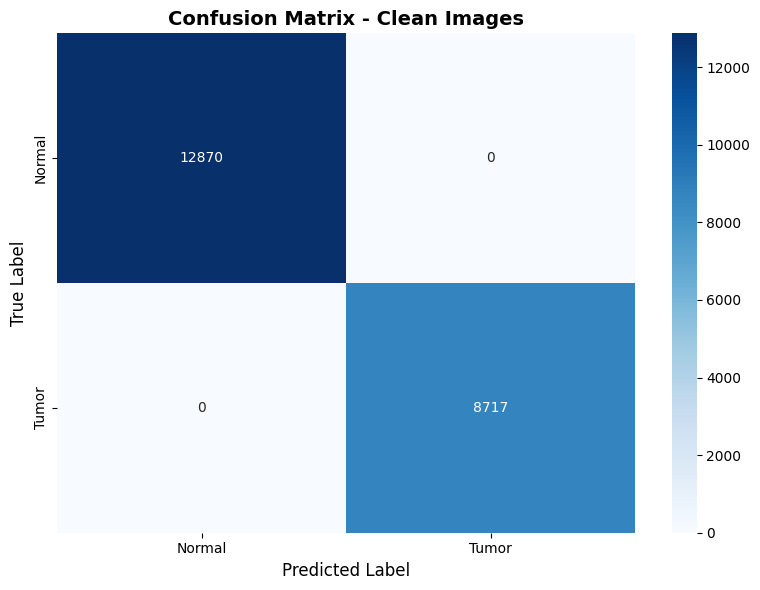


Confusion Matrix - Clean Images:
  TN: 12870  FP:    0  FN:    0  TP: 8717
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000


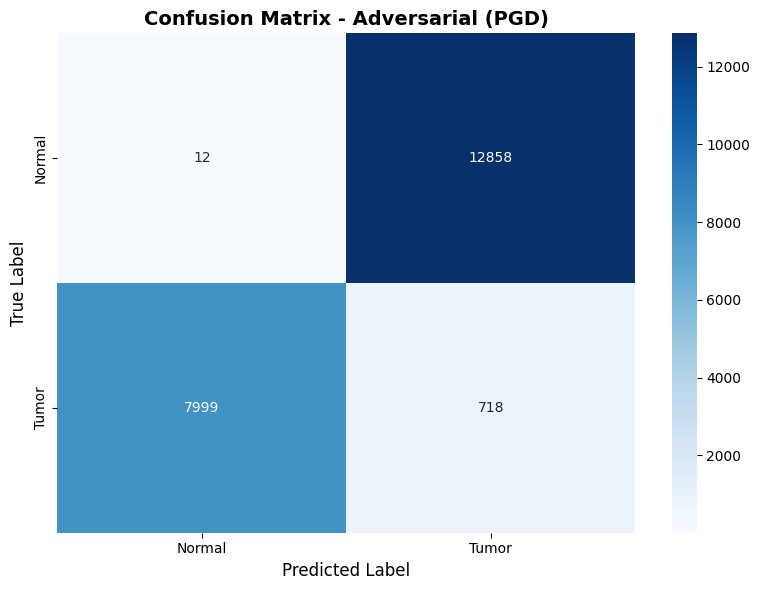


Confusion Matrix - Adversarial (PGD):
  TN:   12  FP: 12858  FN: 7999  TP:  718
  Precision: 0.0529
  Recall:    0.0824
  F1-Score:  0.0644


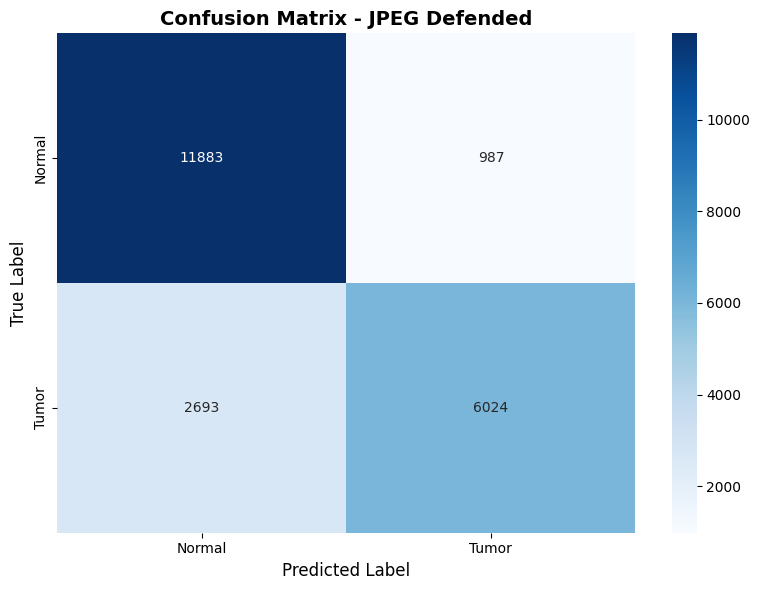


Confusion Matrix - JPEG Defended:
  TN: 11883  FP:  987  FN: 2693  TP: 6024
  Precision: 0.8592
  Recall:    0.6911
  F1-Score:  0.7660


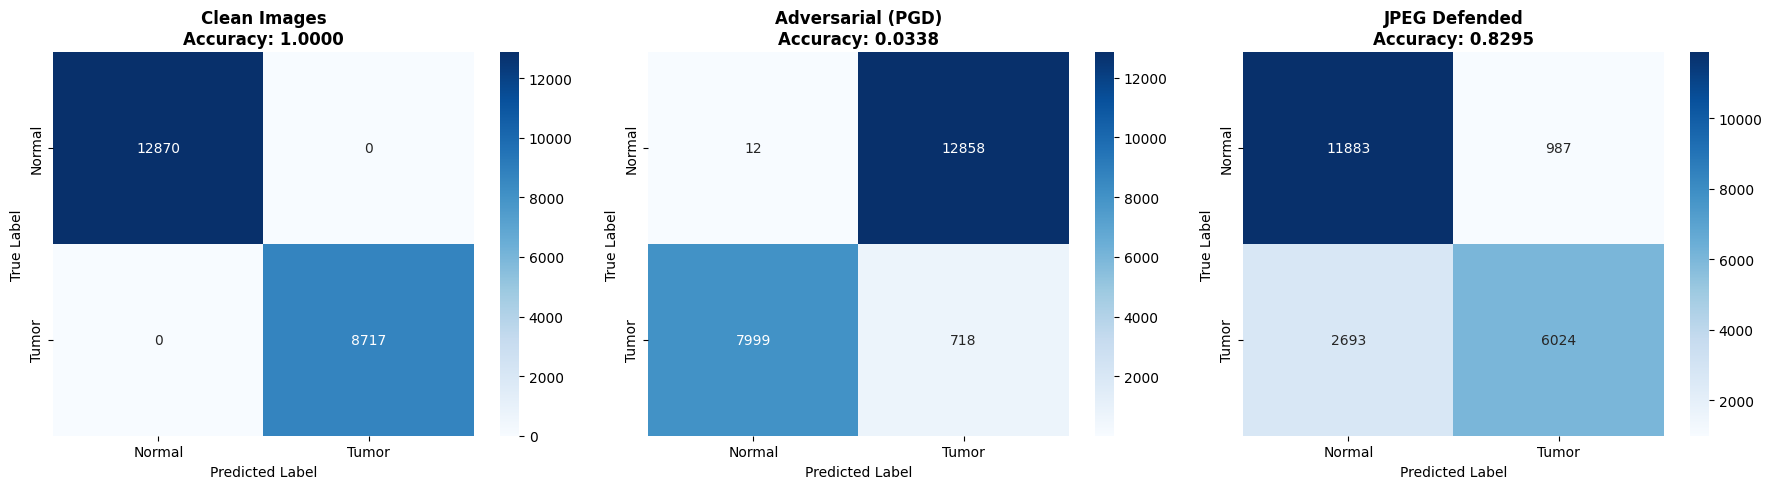


✅ 混同行列保存完了: /mnt/data1/gotou/kaggle/jpeg


In [5]:
# 詳細統計のCSV保存（ddpm_pgd と同等）
import os
import seaborn as sns

csv_path = os.path.join(OUTPUT_DIR, f'jpeg_pgd_detailed_q{jpeg_quality}.csv')
results_df = pd.DataFrame({
    'Sample_ID': list(range(len(all_labels))),
    'True_Label': all_labels.numpy(),
    'Original_Pred': all_preds_clean.numpy(),
    'Adversarial_Pred': all_preds_adv.numpy(),
    'Defended_Pred': all_preds_def.numpy(),
    'l2_norm_adv': l2_norms_adv,
    'linf_norm_adv': linf_norms_adv,
    'l2_norm_defended': l2_norms_purified,
    'linf_norm_defended': linf_norms_purified,
})
results_df['Original_Correct'] = (results_df['Original_Pred'] == results_df['True_Label']).astype(int)
results_df['Attack_Success'] = (results_df['Adversarial_Pred'] != results_df['True_Label']).astype(int)
results_df['Defense_Success'] = (
    (results_df['Attack_Success'] == 1) & (results_df['Defended_Pred'] == results_df['True_Label'])
).astype(int)
results_df['Defense_Recovery'] = ((results_df['Attack_Success'] == 1) & (results_df['Defense_Success'] == 1)).astype(int)

results_df.to_csv(csv_path, index=False)
print(f"\n✅ 詳細結果CSV保存: {csv_path}")

# サマリー統計をテキストファイルに保存
summary_path = os.path.join(OUTPUT_DIR, f'jpeg_pgd_summary_q{jpeg_quality}.txt')
with open(summary_path, 'w') as f:
    f.write("="*70 + "\n")
    f.write("PGD Attack + JPEG Defense - Summary Statistics\n")
    f.write("="*70 + "\n\n")
    f.write("Attack Parameters:\n")
    f.write(f"  Method: PGD (Projected Gradient Descent)\n")
    f.write(f"  Epsilon: {epsilon:.6f} ({epsilon*255:.1f}/255)\n")
    f.write(f"  Alpha: {alpha:.6f} ({alpha*255:.1f}/255)\n")
    f.write(f"  Steps: {pgd_steps}\n")
    f.write(f"  Random Start: True\n\n")
    f.write("Defense Parameters:\n")
    f.write(f"  Method: JPEG Compression\n")
    f.write(f"  Quality: {jpeg_quality}\n\n")
    f.write("-"*70 + "\n")
    f.write(f"Results (evaluated on {total} correctly classified images):\n")
    f.write("-"*70 + "\n")
    f.write(f"Clean Accuracy:      {acc_clean:.4f}\n")
    f.write(f"Adversarial Accuracy:{acc_adv:.4f}\n")
    f.write(f"Defended Accuracy:   {acc_def:.4f}\n")
    f.write(f"Defense Improvement: {acc_def - acc_adv:+.4f}\n")
    f.write(f"Attack Success Rate: {1 - acc_adv:.4f}\n")
    if (total - (all_preds_adv == all_labels).sum().item()) > 0:
        defense_success_rate = ((all_preds_def == all_labels).sum().item() - (all_preds_adv == all_labels).sum().item()) / (total - (all_preds_adv == all_labels).sum().item())
        f.write(f"Defense Success Rate:{defense_success_rate:.4f} (on attacked samples)\n\n")
    else:
        f.write(f"Defense Success Rate: N/A (no successful attacks)\n\n")
    f.write("="*70 + "\n")
    f.write("Perturbation Norms:\n")
    f.write("="*70 + "\n")
    f.write("Adversarial Perturbations (vs Clean):\n")
    f.write(f"  L2 norm:   mean={l2_norms_adv.mean():.6f}, std={l2_norms_adv.std():.6f}\n")
    f.write(f"             min={l2_norms_adv.min():.6f}, max={l2_norms_adv.max():.6f}\n")
    f.write(f"             median={np.median(l2_norms_adv):.6f}\n")
    f.write(f"  L∞ norm:   mean={linf_norms_adv.mean():.6f}, std={linf_norms_adv.std():.6f}\n")
    f.write(f"             min={linf_norms_adv.min():.6f}, max={linf_norms_adv.max():.6f}\n")
    f.write(f"             median={np.median(linf_norms_adv):.6f}\n\n")
    f.write("Defended Images (vs Clean):\n")
    f.write(f"  L2 norm:   mean={l2_norms_purified.mean():.6f}, std={l2_norms_purified.std():.6f}\n")
    f.write(f"             min={l2_norms_purified.min():.6f}, max={l2_norms_purified.max():.6f}\n")
    f.write(f"             median={np.median(l2_norms_purified):.6f}\n")
    f.write(f"  L∞ norm:   mean={linf_norms_purified.mean():.6f}, std={linf_norms_purified.std():.6f}\n")
    f.write(f"             min={linf_norms_purified.min():.6f}, max={linf_norms_purified.max():.6f}\n")
    f.write(f"             median={np.median(linf_norms_purified):.6f}\n\n")
    f.write("="*70 + "\n")
    f.write("Confusion Matrix Statistics:\n")
    f.write("="*70 + "\n")
    for name, preds in [("Clean", all_preds_clean.numpy()), ("Adversarial", all_preds_adv.numpy()), ("Defended", all_preds_def.numpy())]:
        cm = confusion_matrix(all_labels.numpy(), preds)
        tn, fp, fn, tp = cm.ravel()
        precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
        recall = tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1 = (2*precision*recall)/(precision+recall) if (precision+recall)>0 else 0.0
        specificity = tn/(tn+fp) if (tn+fp)>0 else 0.0
        f.write(f"\n{name} Images:\n")
        f.write(f"  TN: {tn:4d}  FP: {fp:4d}  FN: {fn:4d}  TP: {tp:4d}\n")
        f.write(f"  Precision:   {precision:.4f}\n")
        f.write(f"  Recall:      {recall:.4f}\n")
        f.write(f"  F1-Score:    {f1:.4f}\n")
        f.write(f"  Specificity: {specificity:.4f}\n")

print(f"✅ サマリー統計保存: {summary_path}")

# 混同行列の可視化（ddpm_pgd スタイル）
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Tumor'],
                yticklabels=['Normal', 'Tumor'])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}:")
    print(f"  TN: {tn:4d}  FP: {fp:4d}  FN: {fn:4d}  TP: {tp:4d}")
    precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
    recall = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = (2*precision*recall)/(precision+recall) if (precision+recall)>0 else 0.0
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

print("\n" + "="*60)
print("混同行列の可視化")
print("="*60)

plot_confusion_matrix(
    all_labels.numpy(), all_preds_clean.numpy(),
    "Confusion Matrix - Clean Images",
    os.path.join(OUTPUT_DIR, f"cm_clean_pgd_q{jpeg_quality}.png")
)

plot_confusion_matrix(
    all_labels.numpy(), all_preds_adv.numpy(),
    "Confusion Matrix - Adversarial (PGD)",
    os.path.join(OUTPUT_DIR, f"cm_adversarial_pgd_q{jpeg_quality}.png")
)

plot_confusion_matrix(
    all_labels.numpy(), all_preds_def.numpy(),
    "Confusion Matrix - JPEG Defended",
    os.path.join(OUTPUT_DIR, f"cm_defended_pgd_q{jpeg_quality}.png")
)

# 3つ並べて比較
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm_clean = confusion_matrix(all_labels.numpy(), all_preds_clean.numpy())
cm_adv = confusion_matrix(all_labels.numpy(), all_preds_adv.numpy())
cm_def = confusion_matrix(all_labels.numpy(), all_preds_def.numpy())
titles = ['Clean Images', 'Adversarial (PGD)', 'JPEG Defended']
cms = [cm_clean, cm_adv, cm_def]
accs = [acc_clean, acc_adv, acc_def]
for ax, cm, title, acc in zip(axes, cms, titles, accs):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Tumor'],
                yticklabels=['Normal', 'Tumor'])
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'cm_comparison_pgd_q{jpeg_quality}.png'), 
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ 混同行列保存完了: {OUTPUT_DIR}")



ノルム分布の可視化


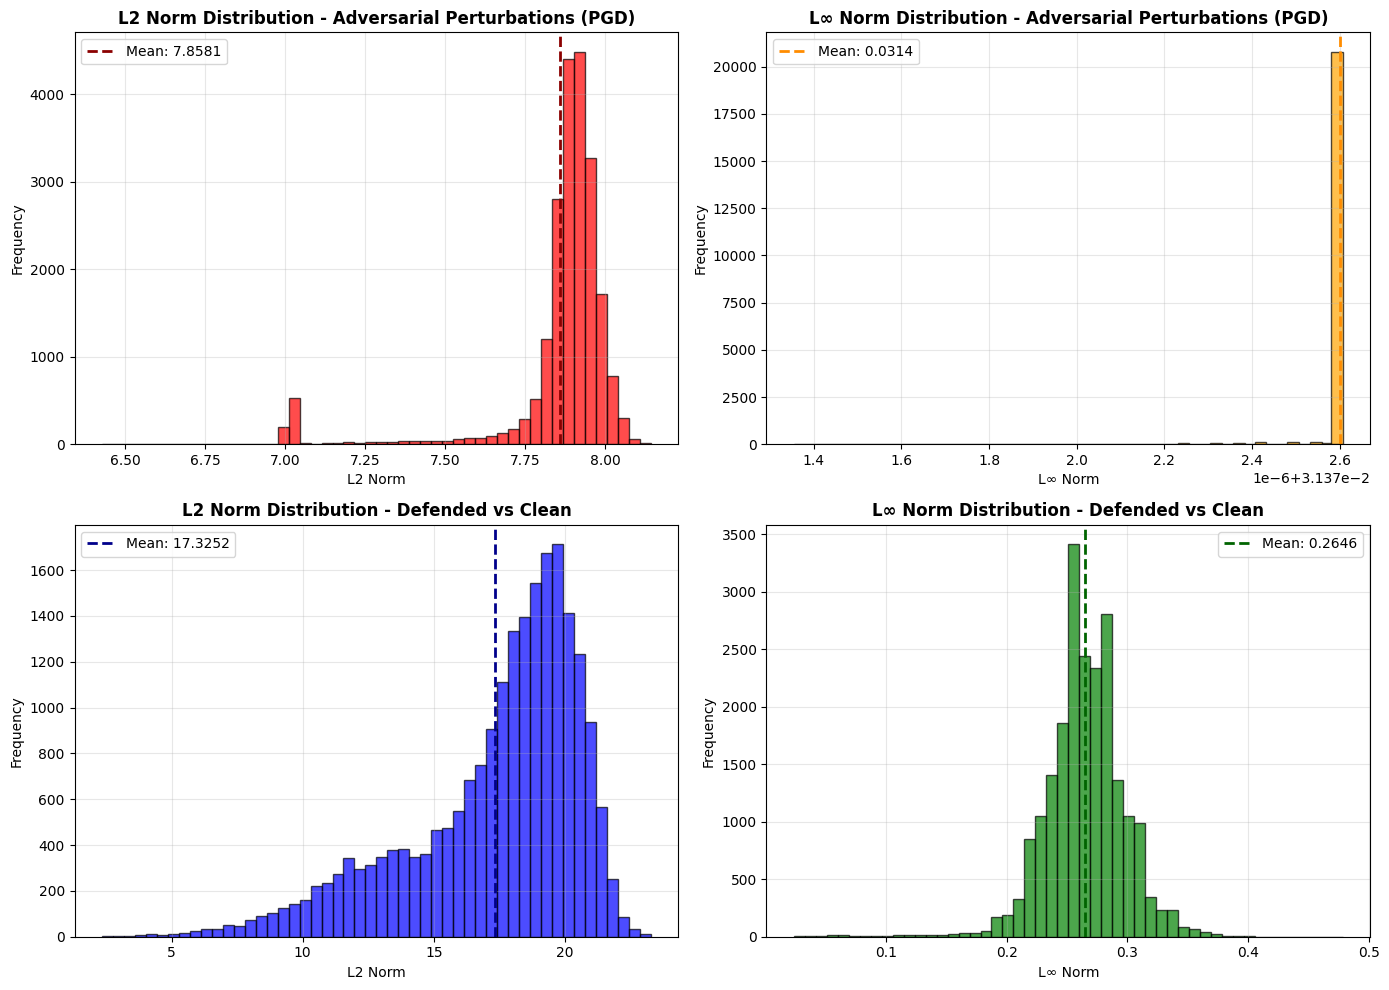

/tmp/ipykernel_667495/230324834.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([l2_norms_adv, l2_norms_purified],
/tmp/ipykernel_667495/230324834.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([linf_norms_adv, linf_norms_purified],


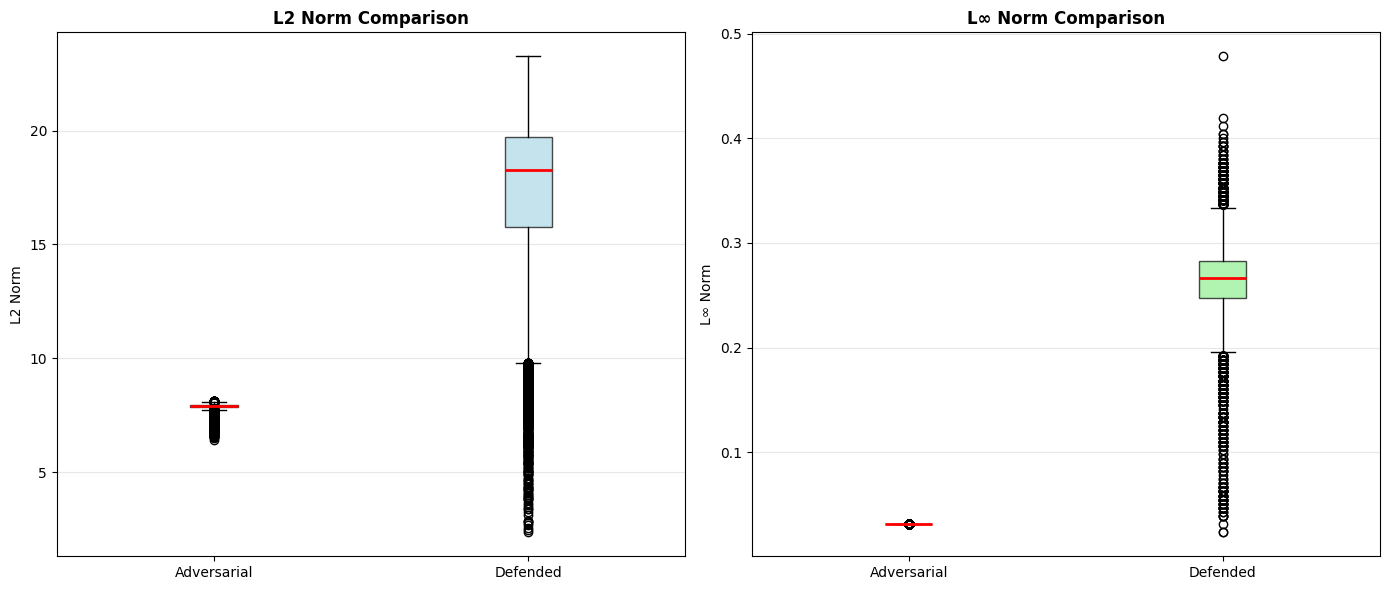


✅ ノルム分布プロット保存完了
   - norm_distributions_pgd_q11.png: L2/L∞ヒストグラム
   - norm_boxplots_pgd_q11.png: ボックスプロット比較


In [6]:
# ノルム分布の可視化（ddpm_pgd と同等）
print("\n" + "="*70)
print("ノルム分布の可視化")
print("="*70)

# L2/L∞ノルムのヒストグラム（4サブプロット）
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# L2 ノルム - Adversarial
axes[0, 0].hist(l2_norms_adv, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(l2_norms_adv.mean(), color='darkred', linestyle='--', linewidth=2, 
                   label=f'Mean: {l2_norms_adv.mean():.4f}')
axes[0, 0].set_title('L2 Norm Distribution - Adversarial Perturbations (PGD)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('L2 Norm')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# L∞ ノルム - Adversarial
axes[0, 1].hist(linf_norms_adv, bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(linf_norms_adv.mean(), color='darkorange', linestyle='--', linewidth=2, 
                   label=f'Mean: {linf_norms_adv.mean():.4f}')
axes[0, 1].set_title('L∞ Norm Distribution - Adversarial Perturbations (PGD)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('L∞ Norm')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# L2 ノルム - Defended
axes[1, 0].hist(l2_norms_purified, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(l2_norms_purified.mean(), color='darkblue', linestyle='--', linewidth=2, 
                   label=f'Mean: {l2_norms_purified.mean():.4f}')
axes[1, 0].set_title('L2 Norm Distribution - Defended vs Clean', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('L2 Norm')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# L∞ ノルム - Defended
axes[1, 1].hist(linf_norms_purified, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(linf_norms_purified.mean(), color='darkgreen', linestyle='--', linewidth=2, 
                   label=f'Mean: {linf_norms_purified.mean():.4f}')
axes[1, 1].set_title('L∞ Norm Distribution - Defended vs Clean', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('L∞ Norm')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'norm_distributions_pgd_q{jpeg_quality}.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

# ボックスプロット比較
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# L2 ノルムの比較
axes[0].boxplot([l2_norms_adv, l2_norms_purified], 
                labels=['Adversarial', 'Defended'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('L2 Norm Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('L2 Norm')
axes[0].grid(True, alpha=0.3, axis='y')

# L∞ ノルムの比較
axes[1].boxplot([linf_norms_adv, linf_norms_purified], 
                labels=['Adversarial', 'Defended'],
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('L∞ Norm Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('L∞ Norm')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'norm_boxplots_pgd_q{jpeg_quality}.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ ノルム分布プロット保存完了")
print(f"   - norm_distributions_pgd_q{jpeg_quality}.png: L2/L∞ヒストグラム")
print(f"   - norm_boxplots_pgd_q{jpeg_quality}.png: ボックスプロット比較")


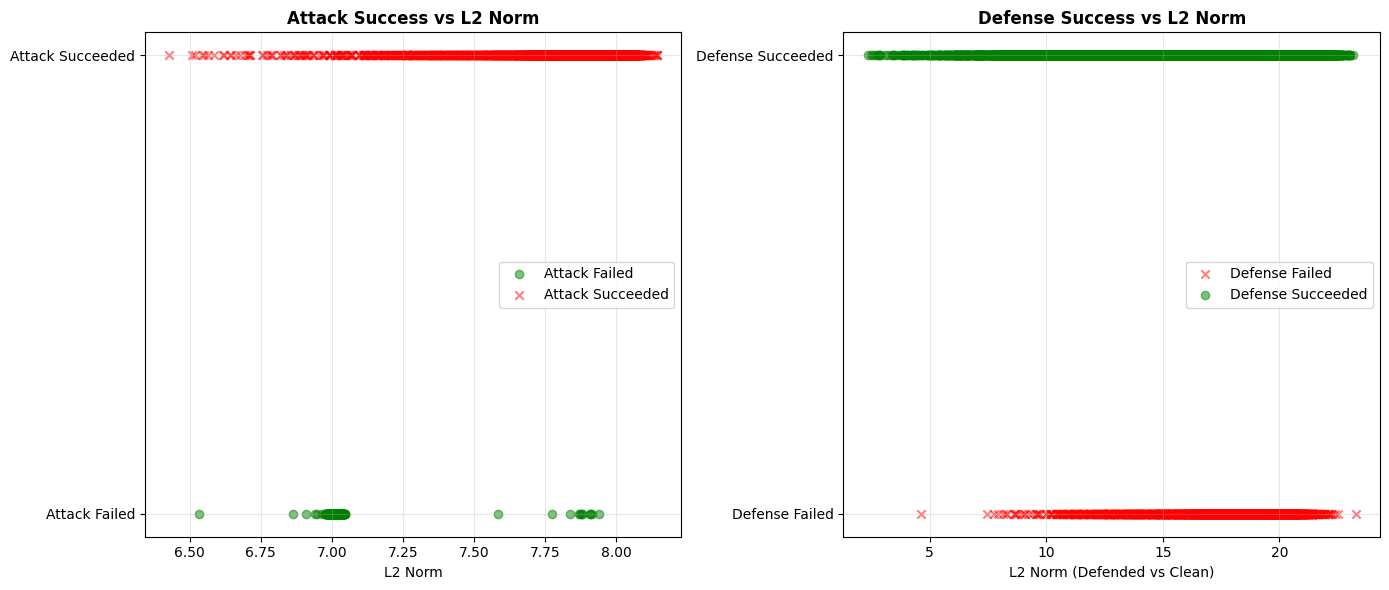


✅ 成功率vs.ノルム散布図保存: success_vs_norms_pgd_q11.png

全ての評価が完了しました！

保存されたファイル:
  - CSV詳細結果: jpeg_pgd_detailed_q11.csv
  - サマリー統計: jpeg_pgd_summary_q11.txt
  - 混同行列 (3枚): cm_clean/adversarial/defended_pgd_q11.png
  - 混同行列比較: cm_comparison_pgd_q11.png
  - ノルム分布: norm_distributions_pgd_q11.png
  - ノルムボックスプロット: norm_boxplots_pgd_q11.png
  - 成功率散布図: success_vs_norms_pgd_q11.png

全て /mnt/data1/gotou/kaggle/jpeg に保存されています。


In [7]:
# 成功率とノルムの散布図（ddpm_pgd と同等）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 攻撃成功/失敗とL2ノルムの関係
attack_success = (all_preds_adv.numpy() != all_labels.numpy())
axes[0].scatter(l2_norms_adv[~attack_success], np.zeros(sum(~attack_success)), 
                c='green', marker='o', alpha=0.5, label='Attack Failed')
axes[0].scatter(l2_norms_adv[attack_success], np.ones(sum(attack_success)), 
                c='red', marker='x', alpha=0.5, label='Attack Succeeded')
axes[0].set_xlabel('L2 Norm')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Attack Failed', 'Attack Succeeded'])
axes[0].set_title('Attack Success vs L2 Norm', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 防御成功/失敗とL2ノルムの関係
defense_success = (all_preds_def.numpy() == all_labels.numpy())
axes[1].scatter(l2_norms_purified[~defense_success], np.zeros(sum(~defense_success)), 
                c='red', marker='x', alpha=0.5, label='Defense Failed')
axes[1].scatter(l2_norms_purified[defense_success], np.ones(sum(defense_success)), 
                c='green', marker='o', alpha=0.5, label='Defense Succeeded')
axes[1].set_xlabel('L2 Norm (Defended vs Clean)')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Defense Failed', 'Defense Succeeded'])
axes[1].set_title('Defense Success vs L2 Norm', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'success_vs_norms_pgd_q{jpeg_quality}.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ 成功率vs.ノルム散布図保存: success_vs_norms_pgd_q{jpeg_quality}.png")

print("\n" + "="*70)
print("全ての評価が完了しました！")
print("="*70)
print(f"\n保存されたファイル:")
print(f"  - CSV詳細結果: jpeg_pgd_detailed_q{jpeg_quality}.csv")
print(f"  - サマリー統計: jpeg_pgd_summary_q{jpeg_quality}.txt")
print(f"  - 混同行列 (3枚): cm_clean/adversarial/defended_pgd_q{jpeg_quality}.png")
print(f"  - 混同行列比較: cm_comparison_pgd_q{jpeg_quality}.png")
print(f"  - ノルム分布: norm_distributions_pgd_q{jpeg_quality}.png")
print(f"  - ノルムボックスプロット: norm_boxplots_pgd_q{jpeg_quality}.png")
print(f"  - 成功率散布図: success_vs_norms_pgd_q{jpeg_quality}.png")
print(f"\n全て {OUTPUT_DIR} に保存されています。")
